# Task 2: Deep Learning – Image Classifier (CIFAR-10)
## Internspark AI Internship

## 1. Import Libraries

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Load & Prepare CIFAR-10 Dataset

In [15]:
# Data augmentation for training
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

# Normalization only for validation/test
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

# Download CIFAR-10
full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Split into train (45k) and validation (5k)
train_data, val_data = random_split(full_train, [45000, 5000])

# Data loaders
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print('Train:', len(train_data), '| Validation:', len(val_data), '| Test:', len(test_data))

Train: 45000 | Validation: 5000 | Test: 10000


## 3. Visualize Sample Images

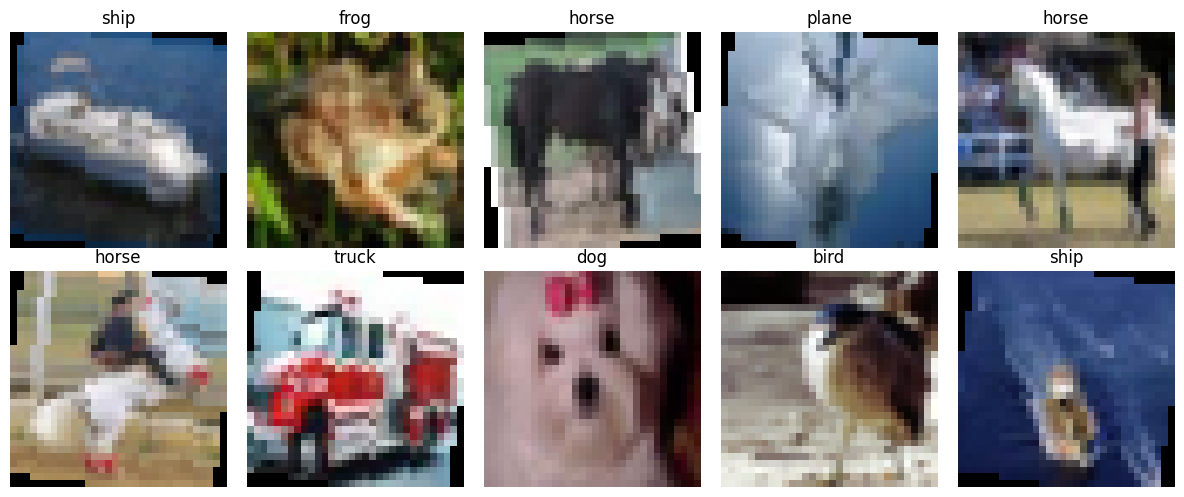

In [16]:
# Show a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i in range(10):
    img = images[i].permute(1, 2, 0)  # CxHxW → HxWxC
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]) + torch.tensor([0.4914, 0.4822, 0.4465])  # unnormalize
    img = torch.clamp(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 4. Load Pretrained ResNet18 & Modify for CIFAR-10

In [17]:
# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify first conv layer for CIFAR-10 (32x32 images instead of 224x224)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()  # remove maxpool

# Replace final fully connected layer for 10 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)
print(model.fc)
print('Total parameters:', sum(p.numel() for p in model.parameters()))

Linear(in_features=512, out_features=10, bias=True)
Total parameters: 11173962


## 5. Training Setup

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

num_epochs = 10

## 6. Training Loop

In [19]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

Epoch 1/10 | Train Loss: 0.8814 | Train Acc: 69.73% | Val Loss: 0.7356 | Val Acc: 74.72%
Epoch 2/10 | Train Loss: 0.5579 | Train Acc: 80.87% | Val Loss: 0.5252 | Val Acc: 82.10%
Epoch 3/10 | Train Loss: 0.4521 | Train Acc: 84.47% | Val Loss: 0.5069 | Val Acc: 82.96%
Epoch 4/10 | Train Loss: 0.3754 | Train Acc: 87.09% | Val Loss: 0.4415 | Val Acc: 85.10%
Epoch 5/10 | Train Loss: 0.3272 | Train Acc: 88.81% | Val Loss: 0.4592 | Val Acc: 84.72%
Epoch 6/10 | Train Loss: 0.1923 | Train Acc: 93.36% | Val Loss: 0.2876 | Val Acc: 90.08%
Epoch 7/10 | Train Loss: 0.1480 | Train Acc: 94.95% | Val Loss: 0.2860 | Val Acc: 90.38%
Epoch 8/10 | Train Loss: 0.1266 | Train Acc: 95.71% | Val Loss: 0.2864 | Val Acc: 90.62%
Epoch 9/10 | Train Loss: 0.1075 | Train Acc: 96.27% | Val Loss: 0.2768 | Val Acc: 90.98%
Epoch 10/10 | Train Loss: 0.0937 | Train Acc: 96.79% | Val Loss: 0.2790 | Val Acc: 91.08%


## 7. Plot Training Curves

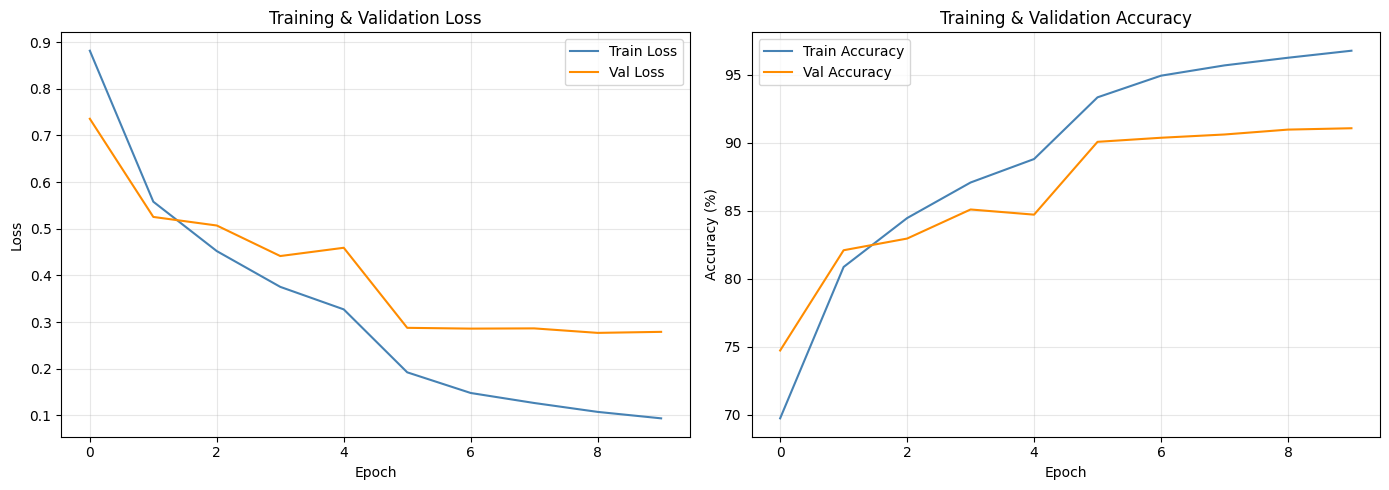

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.plot(val_losses, label='Val Loss', color='darkorange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Accuracy', color='steelblue')
ax2.plot(val_accs, label='Val Accuracy', color='darkorange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

In [21]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Classification report
print('Test Set Results:')
print(classification_report(y_true, y_pred, target_names=classes))

Test Set Results:
              precision    recall  f1-score   support

       plane       0.92      0.94      0.93      1000
         car       0.96      0.97      0.96      1000
        bird       0.88      0.91      0.90      1000
         cat       0.81      0.82      0.82      1000
        deer       0.90      0.94      0.92      1000
         dog       0.88      0.83      0.85      1000
        frog       0.96      0.93      0.95      1000
       horse       0.97      0.94      0.95      1000
        ship       0.95      0.96      0.96      1000
       truck       0.96      0.94      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## 9. Confusion Matrix

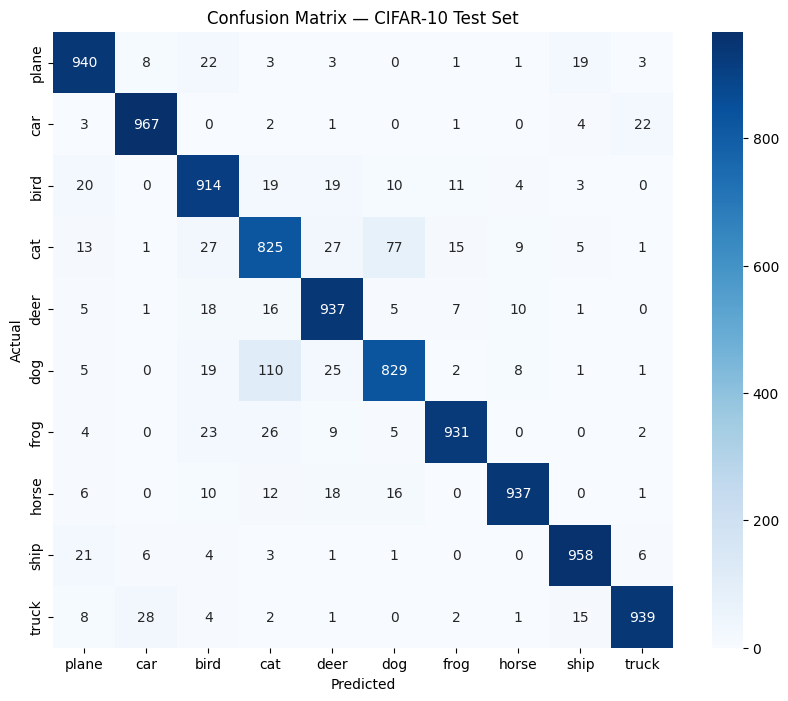

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — CIFAR-10 Test Set')
plt.show()

## 10. Visualize Sample Predictions

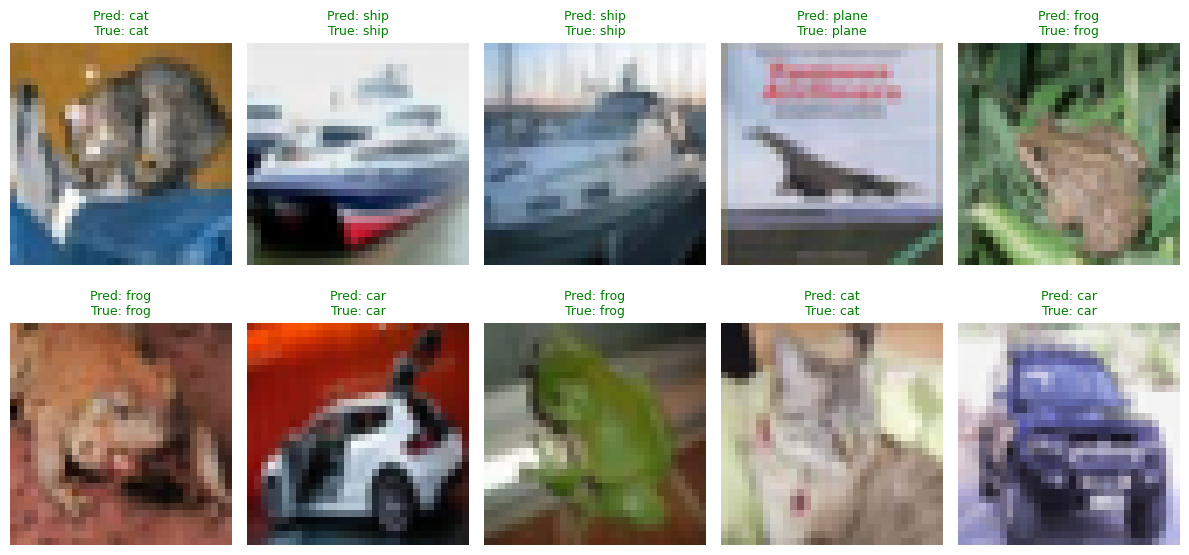

In [23]:
# Get a test batch
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images[:10].to(device), labels[:10].to(device)

outputs = model(images)
_, predicted = outputs.max(1)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()
for i in range(10):
    img = images[i].cpu().permute(1, 2, 0)
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]) + torch.tensor([0.4914, 0.4822, 0.4465])
    img = torch.clamp(img, 0, 1)
    axes[i].imshow(img)
    color = 'green' if predicted[i] == labels[i] else 'red'
    axes[i].set_title(f'Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}', color=color, fontsize=9)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 11. Save Model

In [24]:
torch.save(model.state_dict(), 'cifar10_resnet18.pth')
print('Model saved as cifar10_resnet18.pth')

Model saved as cifar10_resnet18.pth


## 12. Summary

- Built a CIFAR-10 image classifier using transfer learning with pretrained ResNet18.
- Modified the first conv layer for 32×32 images and replaced the final FC layer for 10 classes.
- Trained for 10 epochs with data augmentation (RandomHorizontalFlip, RandomRotation) and StepLR scheduler.
- **Final Results:**
  - Train Accuracy: 96.79% | Val Accuracy: 91.08%
  - Test Accuracy: 91.77%
  - Train Loss: 0.0937 | Val Loss: 0.2790
- Minimal overfitting (train-val gap ~5.7%), indicating good generalization.
- **Common confusions (from confusion matrix):**
  - Cat ↔ Dog: 187 misclassifications (visually similar animals)
  - Car ↔ Truck: 50 misclassifications (similar vehicle shapes)
  - Bird ↔ Cat: 46 misclassifications
- These confusions are intuitive and match human-level difficulty for these class pairs.
- Model saved as `cifar10_resnet18.pth` for deployment.